In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", context="talk", palette="muted")

In [ ]:
data = pd.read_csv("Iris.csv")
data.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
18,19,5.7,3.8,1.7,0.3,Iris-setosa
65,66,6.7,3.1,4.4,1.4,Iris-versicolor
38,39,4.4,3.0,1.3,0.2,Iris-setosa
16,17,5.4,3.9,1.3,0.4,Iris-setosa
108,109,6.7,2.5,5.8,1.8,Iris-virginica


In [ ]:
data.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
# renaming columns
data.rename(columns = {'SepalLengthCm':'SL', 'SepalWidthCm':'SW', 'PetalLengthCm':'PL', 'PetalWidthCm':'PW'}, inplace=True)

In [ ]:
data.tail()

,Id,SL,SW,PL,PW,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
data["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
iris_setosa = data[data['Species'] == "Iris-setosa"] # dataframe of rows with species as Iris-setosa
iris_versicolor = data[data['Species'] == "Iris-versicolor"]
iris_virginica = data[data['Species'] == "Iris-virginica"]

## 1. Mean

In [ ]:
# Sepel Width
print(np.mean(iris_setosa['SW']))
print(np.mean(iris_versicolor['SW']))
print(np.mean(iris_virginica['SW']))

3.418
2.7700000000000005
2.974


In [ ]:
# Sepel Length
print(np.mean(iris_setosa['SL']))
print(np.mean(iris_versicolor['SL']))
print(np.mean(iris_virginica['SL']))

5.006
5.936
6.587999999999998


In [ ]:
# Petal Width
print(np.mean(iris_setosa['PW']))
print(np.mean(iris_versicolor['PW']))
print(np.mean(iris_virginica['PW']))

0.244
1.3259999999999998
2.0260000000000002


In [ ]:
# Petal Length
print(np.mean(iris_setosa['PL']))
print(np.mean(iris_versicolor['PL']))
print(np.mean(iris_virginica['PL']))

1.464
4.26
5.5520000000000005


## The Problem of Outliers

We cant use mean when there are outliers

(array([ 1.,  1.,  2.,  7., 12., 14.,  7.,  4.,  0.,  2.]),
 array([1.  , 1.09, 1.18, 1.27, 1.36, 1.45, 1.54, 1.63, 1.72, 1.81, 1.9 ]),
 <BarContainer object of 10 artists>)

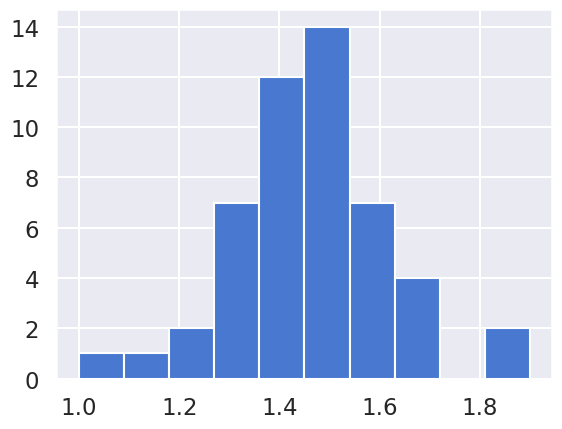

In [ ]:
# Range of Setosa Petal Width is between 1 and 2
plt.hist(iris_setosa['PL'])

In [ ]:
# If we append an outlier at the end of the petal length of iris_setosa
np.mean(np.append(iris_setosa['PL'], 50))

np.float64(2.4156862745098038)

In [ ]:
# The mean shifts away from the actual range of PL of iris_setosa i.e. 1 to 2
# If the data contains any outliers then the mean will get skewed

## Median

The solution of above issue, if there is any outlier the mean will be useless so we use median.

[1, 3, 3, 6, 7, 8, 9] Median = 6

[1, 2, 3, 4, 5, 6, 8, 9] Median = (4+5)/2 = 4.5

The outlier doesnot put any impact over outliers.

In [ ]:
# Petal Length
print(np.median(iris_setosa['PL']))
print(np.median(iris_versicolor['PL']))
print(np.median(iris_virginica['PL']))

1.5
4.35
5.55


### The good thing about median

In [ ]:
# The values are in range of 1 and 2 for petal length of iris_setosa. If we find median after adding an outlier 50 we still get in the range of 1 and 2
np.median(np.append(iris_setosa['PL'], 50))

np.float64(1.5)

In [41]:
arr = np.array([1, 4, 5, 8, 12, 600, 700, 800, 100000]) # the last 4 numbers are outliers way bigger
np.median(arr)

np.float64(12.0)

In [42]:
# The median will be unaffected uptill when 50% of data is outlier (.: like in above example)

## Mode

Calculate the frequency count of all the number, The number with <b>higher frequency count</b> will become <b>Mode</b>.

Example : [6, 3, 9, 6, 6, 5, 9, 3]

Frequency Count : 6 -> 3, 3 -> 2, 9 -> 2, 5 -> 1

Mode = 6

In [43]:
from scipy import stats
# Petal Length
print(stats.mode(iris_setosa['PL']))
print(stats.mode(iris_versicolor['PL']))
print(stats.mode(iris_virginica['PL']))

ModeResult(mode=np.float64(1.5), count=np.int64(14))
ModeResult(mode=np.float64(4.5), count=np.int64(7))
ModeResult(mode=np.float64(5.1), count=np.int64(7))


## Which one should You use?

We should use all three to have a fair idea of the centrality of the data.